In [7]:
# Cell 1: Load transition→datetimes from log, then build wait_time_list + raw_file_paths_list
import os
import re
from datetime import datetime
from collections import defaultdict
import io
# -----------------------
# User configuration
# -----------------------
# directory_path = r'Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Raw_data_PD'   # contains Ramsey_experiment_* PD files
# Z_drive_raw_data = r'Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Raw_data\\'  # contains raw JSONL files
# log_path = r'bussed_ramsey_for_line_signal.txt'   # your text log file

directory_path = r'Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Raw_data_PD'   # contains Ramsey_experiment_* PD files
Z_drive_raw_data = r'Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Raw_data\\'  # contains raw JSONL files
# log_path = r'bussed_ramsey_for_line_signal.txt'   # your text log file
# log_path = r'bussed_ramsey_detuning_calibration.txt'
# log_path = r'Bussed_Ramsey_datetime_log.txt'
log_path = r'Bussed_ramsey_consistancy_check_log.txt'
directory_path = r'Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Bussed_ramsey_detuning_calibration_data\\'

# Choose ONE transition pair for this notebook run (edit these)
target_transitions = [[2, 4, 2], [2, 3, 0]]  # [[m,F,mF],[m,F,mF]]

# -----------------------
# Helpers (Cell 1)
# -----------------------
def parse_filename(filename):
    pattern = (
        r"Ramsey_experiment_\[\[(-?\d+),\s*(-?\d+),\s*(-?\d+)\],\s*"
        r"\[(-?\d+),\s*(-?\d+),\s*(-?\d+)\]\]_(\d+(?:\.\d+)?)_us_(\d+)_"
        r"(\d{8})_(\d{4})"
    )
    match = re.search(pattern, filename)
    if match:
        m1  = int(match.group(1))
        F1  = int(match.group(2))
        mF1 = int(match.group(3))
        m2  = int(match.group(4))
        F2  = int(match.group(5))
        mF2 = int(match.group(6))

        wait_time = float(match.group(7))   # e.g. 16800.1
        comp_flag = int(match.group(8))     # e.g. 0 or 1

        date_str = match.group(9) + match.group(10)  # "YYYYMMDDHHMM"
        date_time = datetime.strptime(date_str, '%Y%m%d%H%M')

        transitions = [(m1, F1, mF1), (m2, F2, mF2)]
        return transitions, wait_time, date_time, comp_flag
    else:
        return None, None, None, None

def extract_raw_data_filenames(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    raw_data_filenames_line = lines[-1].strip()
    raw_data_filenames = [
        name.strip().strip("'\"") for name in raw_data_filenames_line.strip('[]').split(',')
    ]
    return raw_data_filenames

def search_files_by_transitions(directory, target_transitions, target_date_times=None):
    """
    target_transitions: list like [[0, 2, 0], [0, 4, -2]]
    target_date_times: set(datetime) or None
    """
    target_transitions = [tuple(t) for t in target_transitions]

    wait_time_list = []
    raw_file_paths_list = []
    final_transitions = None

    for filename in os.listdir(directory):
        if filename.startswith('Ramsey_experiment'):
            transitions, wait_time, date_time, comp_flag = parse_filename(filename)
            if transitions is None or wait_time is None or date_time is None:
                continue

            # exact match of the two transitions (order matters)
            if transitions == target_transitions:
                if target_date_times and date_time not in target_date_times:
                    continue

                final_transitions = transitions
                file_path = os.path.join(directory, filename)

                raw_data_filenames = extract_raw_data_filenames(file_path)
                raw_data_filepaths = [
                    os.path.join(Z_drive_raw_data, raw_filename)
                    for raw_filename in raw_data_filenames
                ]

                wait_time_list.append(wait_time)
                raw_file_paths_list.append(raw_data_filepaths)

    return wait_time_list, raw_file_paths_list, final_transitions


import re
from datetime import datetime

def parse_log_file_for_pair(log_path, target_transitions, LT_comp: bool):
    """
    Reads your log text file and returns:
      - dt_set: set(datetime) chosen from Comp False or Comp True list based on LT_comp
      - mean_dev: float mean deviation for that transition pair (or None if not found)

    Expected line formats (tolerant):
      [[a,b,c],[d,e,f]] 21.19
      [[a,b,c],[d,e,f]], 21.19
      [[a,b,c],[d,e,f]], 21.19, ['YYYYMMDD_HHMM', ...], ['YYYYMMDD_HHMM', ...]
    where list1 = Comp False, list2 = Comp True.
    """

    # Normalize target to tuple-of-tuples (order matters)
    tkey = (tuple(target_transitions[0]), tuple(target_transitions[1]))

    dt_set = set()
    mean_dev = None

    # helper: parse 'YYYYMMDD_HHMM' -> datetime
    def _tok_to_dt(tok: str) -> datetime:
        return datetime.strptime(tok.replace("_", ""), "%Y%m%d%H%M")

    with open(log_path, "r") as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line:
                continue

            # Skip header-ish lines
            if line.lower().startswith("transition"):
                continue

            # 1) Grab the transition literal by slicing up to the first ']]'
            end = line.find("]]")
            if end == -1:
                continue  # not a data line

            trans_str = line[: end + 2].strip()  # includes the closing ']]'
            rest = line[end + 2 :].strip()       # everything after transitions

            # Parse transitions: extract the six ints
            # trans_str looks like: [[0, 3, -1], [0, 2, 0]]
            m = re.match(
                r"^\s*\[\s*\[\s*(-?\d+)\s*,\s*(-?\d+)\s*,\s*(-?\d+)\s*\]\s*,\s*"
                r"\[\s*(-?\d+)\s*,\s*(-?\d+)\s*,\s*(-?\d+)\s*\]\s*\]\s*$",
                trans_str,
            )
            if not m:
                continue

            p1 = (int(m.group(1)), int(m.group(2)), int(m.group(3)))
            p2 = (int(m.group(4)), int(m.group(5)), int(m.group(6)))
            key = (p1, p2)
            if key != tkey:
                continue

            # 2) Parse mean deviation: first float in "rest"
            # rest might start with "," or not.
            rest_clean = rest.lstrip(",").strip()

            mf = re.search(r"([-+]?\d+(?:\.\d+)?(?:[eE][-+]?\d+)?)", rest_clean)
            if not mf:
                # matched transition but no mean; keep scanning
                continue

            mean_dev = float(mf.group(1))

            # 3) Find datetime-lists: any bracketed list containing quoted YYYYMMDD_HHMM tokens
            # We'll interpret the first such list as Comp False, second as Comp True.
            list_blobs = re.findall(r"\[(.*?)\]", rest_clean)  # contents of all [...] blocks
            dt_lists = []
            for blob in list_blobs:
                toks = re.findall(r"['\"](\d{8}_\d{4})['\"]", blob)
                if toks:
                    dt_lists.append(toks)

            comp_false_toks = dt_lists[0] if len(dt_lists) >= 1 else []
            comp_true_toks  = dt_lists[1] if len(dt_lists) >= 2 else []

            chosen = comp_true_toks if LT_comp else comp_false_toks
            for tok in chosen:
                dt_set.add(_tok_to_dt(tok))

            # If your log could contain multiple identical transition lines and you want to MERGE,
            # then DO NOT break here. If you expect exactly one, you can break.
            # I'll keep merging across multiple lines (safer).
            # continue scanning

    return dt_set, mean_dev

# -----------------------
# Run Cell 1
# -----------------------
LT_comp = False  # Set to True to use Comp True datetimes instead of Comp False
target_transitions = [[0,3, 2], [0,2,0]]
target_date_times, mean_dev = parse_log_file_for_pair(log_path, target_transitions, LT_comp = LT_comp)
if len(target_date_times) == 0:
    raise ValueError(f"No datetimes found in log for transition pair: {target_transitions}")

wait_time_list, raw_file_paths_list, final_transitions = search_files_by_transitions(
    directory_path, target_transitions, target_date_times
)

print(f"Transitions found: {final_transitions}")
print(f"Matched datetimes (from log): {[dt.strftime('%Y%m%d_%H%M') for dt in sorted(target_date_times)]}")
print(f"Found {len(wait_time_list)} Ramsey PD files for this pair.")

# These two variables are what Cell 2 expects:
#   wait_time_list
#   raw_file_paths_list


Transitions found: [(0, 3, 2), (0, 2, 0)]
Matched datetimes (from log): ['20260421_1547', '20260422_1554', '20260422_1613', '20260422_1632', '20260422_1651', '20260422_1712']
Found 42 Ramsey PD files for this pair.


## Cell 2: Analyze raw data files and save PD

In [8]:
import numpy as np
import json

# --------------------------------
# Existing Functions (Unchanged)
# --------------------------------

def getShelvingThreshold(counts):
    data_sorted = np.sort(counts, axis=None)
    # print("Total sorted data points:", len(data_sorted))
    # Remove extreme ends (if possible)
    if len(data_sorted) > 4000:
        data_sorted = data_sorted[2000:-2000]
    if len(data_sorted) > 2000:
        step = round(data_sorted.size / (len(counts) * 0.0250167))
        if step < 1:
            step = 1
        data_sorted = data_sorted[0:-1:step]
    data_sorted_diff = data_sorted[1:-1] - data_sorted[0:-2]
    data_diff_max = max(data_sorted_diff)
    data_diff_maxind = np.argmax(data_sorted_diff)
    threshold = data_diff_max / 2 + data_sorted[data_diff_maxind]
    
    # New logic: if the calculated threshold is less than 2, recalculate using histogram data.
    # if threshold < 2:
        # Calculate histogram in the x-range 4 to 30
    hist_counts, bin_edges = np.histogram(counts, bins=range(4, 31))
    # Find the bin (lowest bar) with the minimum count in that range
    min_bin_index = np.argmin(hist_counts)
    # Use the lower edge of that bin as the threshold
    threshold = bin_edges[min_bin_index] + 0.5

    if threshold < 2 or threshold > 20:
        threshold = 11

    print(f"Threshold recalculated using histogram: {threshold}")
    
    return threshold, data_sorted

def process_raw_data_files(raw_data_filepaths, ket_1_first):
    arrays = []
    # Read and process the data from all raw data files
    # print(raw_data_filepaths)
    for file_path in raw_data_filepaths:
        with open(file_path, 'r') as file:
            for line in file:
                data = json.loads(line)
                arrays.append(data[0]["0"])
    # Convert to numpy array
    hist_data = np.array(arrays)
    
    # Flatten the hist_data and compute shelving threshold
    flat_hist_data = hist_data.flatten()
    threshold, _ = getShelvingThreshold(flat_hist_data)

    # Prepare for further processing (3D array)
    arrays_3d = []
    for file_path in raw_data_filepaths[:]:
        arrays = []
        with open(file_path, 'r') as file:
            for line in file:
                data = json.loads(line)
                arrays.append(data[0]["0"][:])
        if len(arrays) == 0:
            arrays = list(np.full((100, 3), 40))  # fallback if no data
        arrays_3d.append(arrays)

    bool_array = np.array(arrays_3d) > threshold
    print(bool_array.shape)
    print(threshold)
    result_matrix = np.full(bool_array.shape, False, dtype=bool)
    # Identify the first occurrence of shelving (True value)
    if bool_array.shape[2] < 3:
        result_matrix = np.full(bool_array.shape + np.array([0,0,1]), False, dtype=bool)
        print("Warning: Expected at least 3 columns in the data for shelving detection.")
        for matrix_index in range(bool_array.shape[0]):
            for row_index in range(bool_array.shape[1]):
                true_indices = np.where(bool_array[matrix_index, row_index, :])
                data_bool = bool_array[matrix_index, row_index, :]
                if data_bool[0] == False:
                    if data_bool[1] == True:
                        result_matrix[matrix_index, row_index, 1] = True
                    if data_bool[1] == False:
                        result_matrix[matrix_index, row_index, 2] = True
    else:
        for matrix_index in range(bool_array.shape[0]):
            for row_index in range(bool_array.shape[1]):
                true_indices = np.where(bool_array[matrix_index, row_index, :])
                data_bool = bool_array[matrix_index, row_index, :]
                if data_bool[0] == False:
                    if data_bool[1] == True:
                        result_matrix[matrix_index, row_index, 1] = True
                    if data_bool[1] == False:
                        result_matrix[matrix_index, row_index, 2] = True

    # Filter data and compute percentages used
    filtered_data_array = []
    percentage_data_used = []
    num_points = bool_array.shape[0]  # Determine the number of data points
    for i in range(num_points):
        data = result_matrix[i]
        rows_with_any_true = data.any(axis=1)
        filtered_data = data[rows_with_any_true]
        filtered_data_array.append(filtered_data)
        percentage_data_used.append(filtered_data.shape[0] / data.shape[0])

    # Compute ket data by averaging the filtered data
    def find_errors(num_SD, full_data_array, exp_num):
        upper_error = ((full_data_array + (num_SD**2 / (2 * exp_num))) /
                       (1 + (num_SD**2 / exp_num))) + np.sqrt(
                           ((full_data_array *
                             (1 - full_data_array) * num_SD**2) / exp_num) +
                           (num_SD**4 / (4 * exp_num**2))
                       ) / (1 + (num_SD**2 / exp_num))

        lower_error = ((full_data_array + (num_SD**2 / (2 * exp_num))) /
                       (1 + (num_SD**2 / exp_num))) - np.sqrt(
                           ((full_data_array *
                             (1 - full_data_array) * num_SD**2) / exp_num) +
                           (num_SD**4 / (4 * exp_num**2))
                       ) / (1 + (num_SD**2 / exp_num))

        return lower_error, upper_error

    ket_data = []
    exp_num_list = []
    for filtered_data in filtered_data_array:
        # if ket_1_first:
        #     ket_data.append(np.mean(filtered_data, axis=0)[2])
        # else:
        ket_data.append(np.mean(filtered_data, axis=0)[1])
        exp_num_list.append(len(filtered_data))
    print(exp_num_list)
    lower_error, upper_error = find_errors(1, np.array(ket_data), np.array(exp_num_list))
    
    return ket_data, lower_error, upper_error


# ------------------------------------------------
# New Function Using Parallel Lists (NOT a dict)
# ------------------------------------------------
def process_all_wait_times_in_lists(wait_time_list, raw_file_paths_list, ket_1_first = False):
    processed_wait_times = []
    ket_data_list = []
    lower_error_list = []
    upper_error_list = []
    
    for i, wait_time in enumerate(wait_time_list):
        raw_data_filepaths = raw_file_paths_list[i]
        print('-------------------------------------------------------------------------')
        print('Wait time:', wait_time, 'Processing files:', raw_data_filepaths[0])
        ket_data, lower_error, upper_error = process_raw_data_files(raw_data_filepaths, ket_1_first)

        processed_wait_times.append(wait_time)

        ket_data_arr = np.array(ket_data)
        final_lower_error = np.abs(ket_data_arr - np.array(lower_error))
        final_upper_error = np.abs(np.array(upper_error) - ket_data_arr)

        ket_data_list.append(ket_data)
        lower_error_list.append(final_lower_error)
        upper_error_list.append(final_upper_error)

    return processed_wait_times, ket_data_list, lower_error_list, upper_error_list


# --------------------------------------------
# ONLY AMENDMENT: safe sorting / conversion
# --------------------------------------------
if len(wait_time_list) == 0:
    raise ValueError("wait_time_list is empty (nothing to process).")

wait_time_list, raw_file_paths_list = zip(
    *sorted(zip(wait_time_list, raw_file_paths_list), key=lambda x: x[0])
)

wait_time_list = list(wait_time_list)
raw_file_paths_list = list(raw_file_paths_list)

(
    processed_wait_times, 
    ket_data_list, 
    lower_error_list, 
    upper_error_list
) = process_all_wait_times_in_lists(wait_time_list, raw_file_paths_list, ket_1_first = False)

print("\nProcessed Data in Parallel Lists:")
for wt, ket_vals, le_vals, ue_vals in zip(processed_wait_times, ket_data_list, lower_error_list, upper_error_list):
    print(f"\nWait Time: {wt} us")
    print(f"Ket Data (list): {ket_vals}")
    print(f"Lower Error (array): {le_vals}")
    print(f"Upper Error (array): {ue_vals}")


-------------------------------------------------------------------------
Wait time: 0.0 Processing files: Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Raw_data_copied\\2026\\2026_04\\2026_04_21\\qudit_ramsey_scan_bused_342
Threshold recalculated using histogram: 8.5
(6, 100, 2)
8.5
[70, 67, 73, 74, 73, 76]
-------------------------------------------------------------------------
Wait time: 0.0 Processing files: Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Raw_data_copied\\2026\\2026_04\\2026_04_22\\qudit_ramsey_scan_bused_722
Threshold recalculated using histogram: 10.5
(6, 100, 2)
10.5
[97, 99, 100, 98, 97, 96]
-------------------------------------------------------------------------
Wait time: 0.0 Processing files: Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Raw_data_copied\\2026\\2026_04\\2026_04_22\\qudit_ramsey_scan_bused_820
Threshold recalculated using histogram: 8.5
(6, 100, 2)
8.5
[99, 98, 98, 98, 98, 98]
-------------------------------------------------------------------------
Wait time: 0.0 Proce

## Cell 3: Analyze and fit the Ramsey scans and output Amplitudes and phases

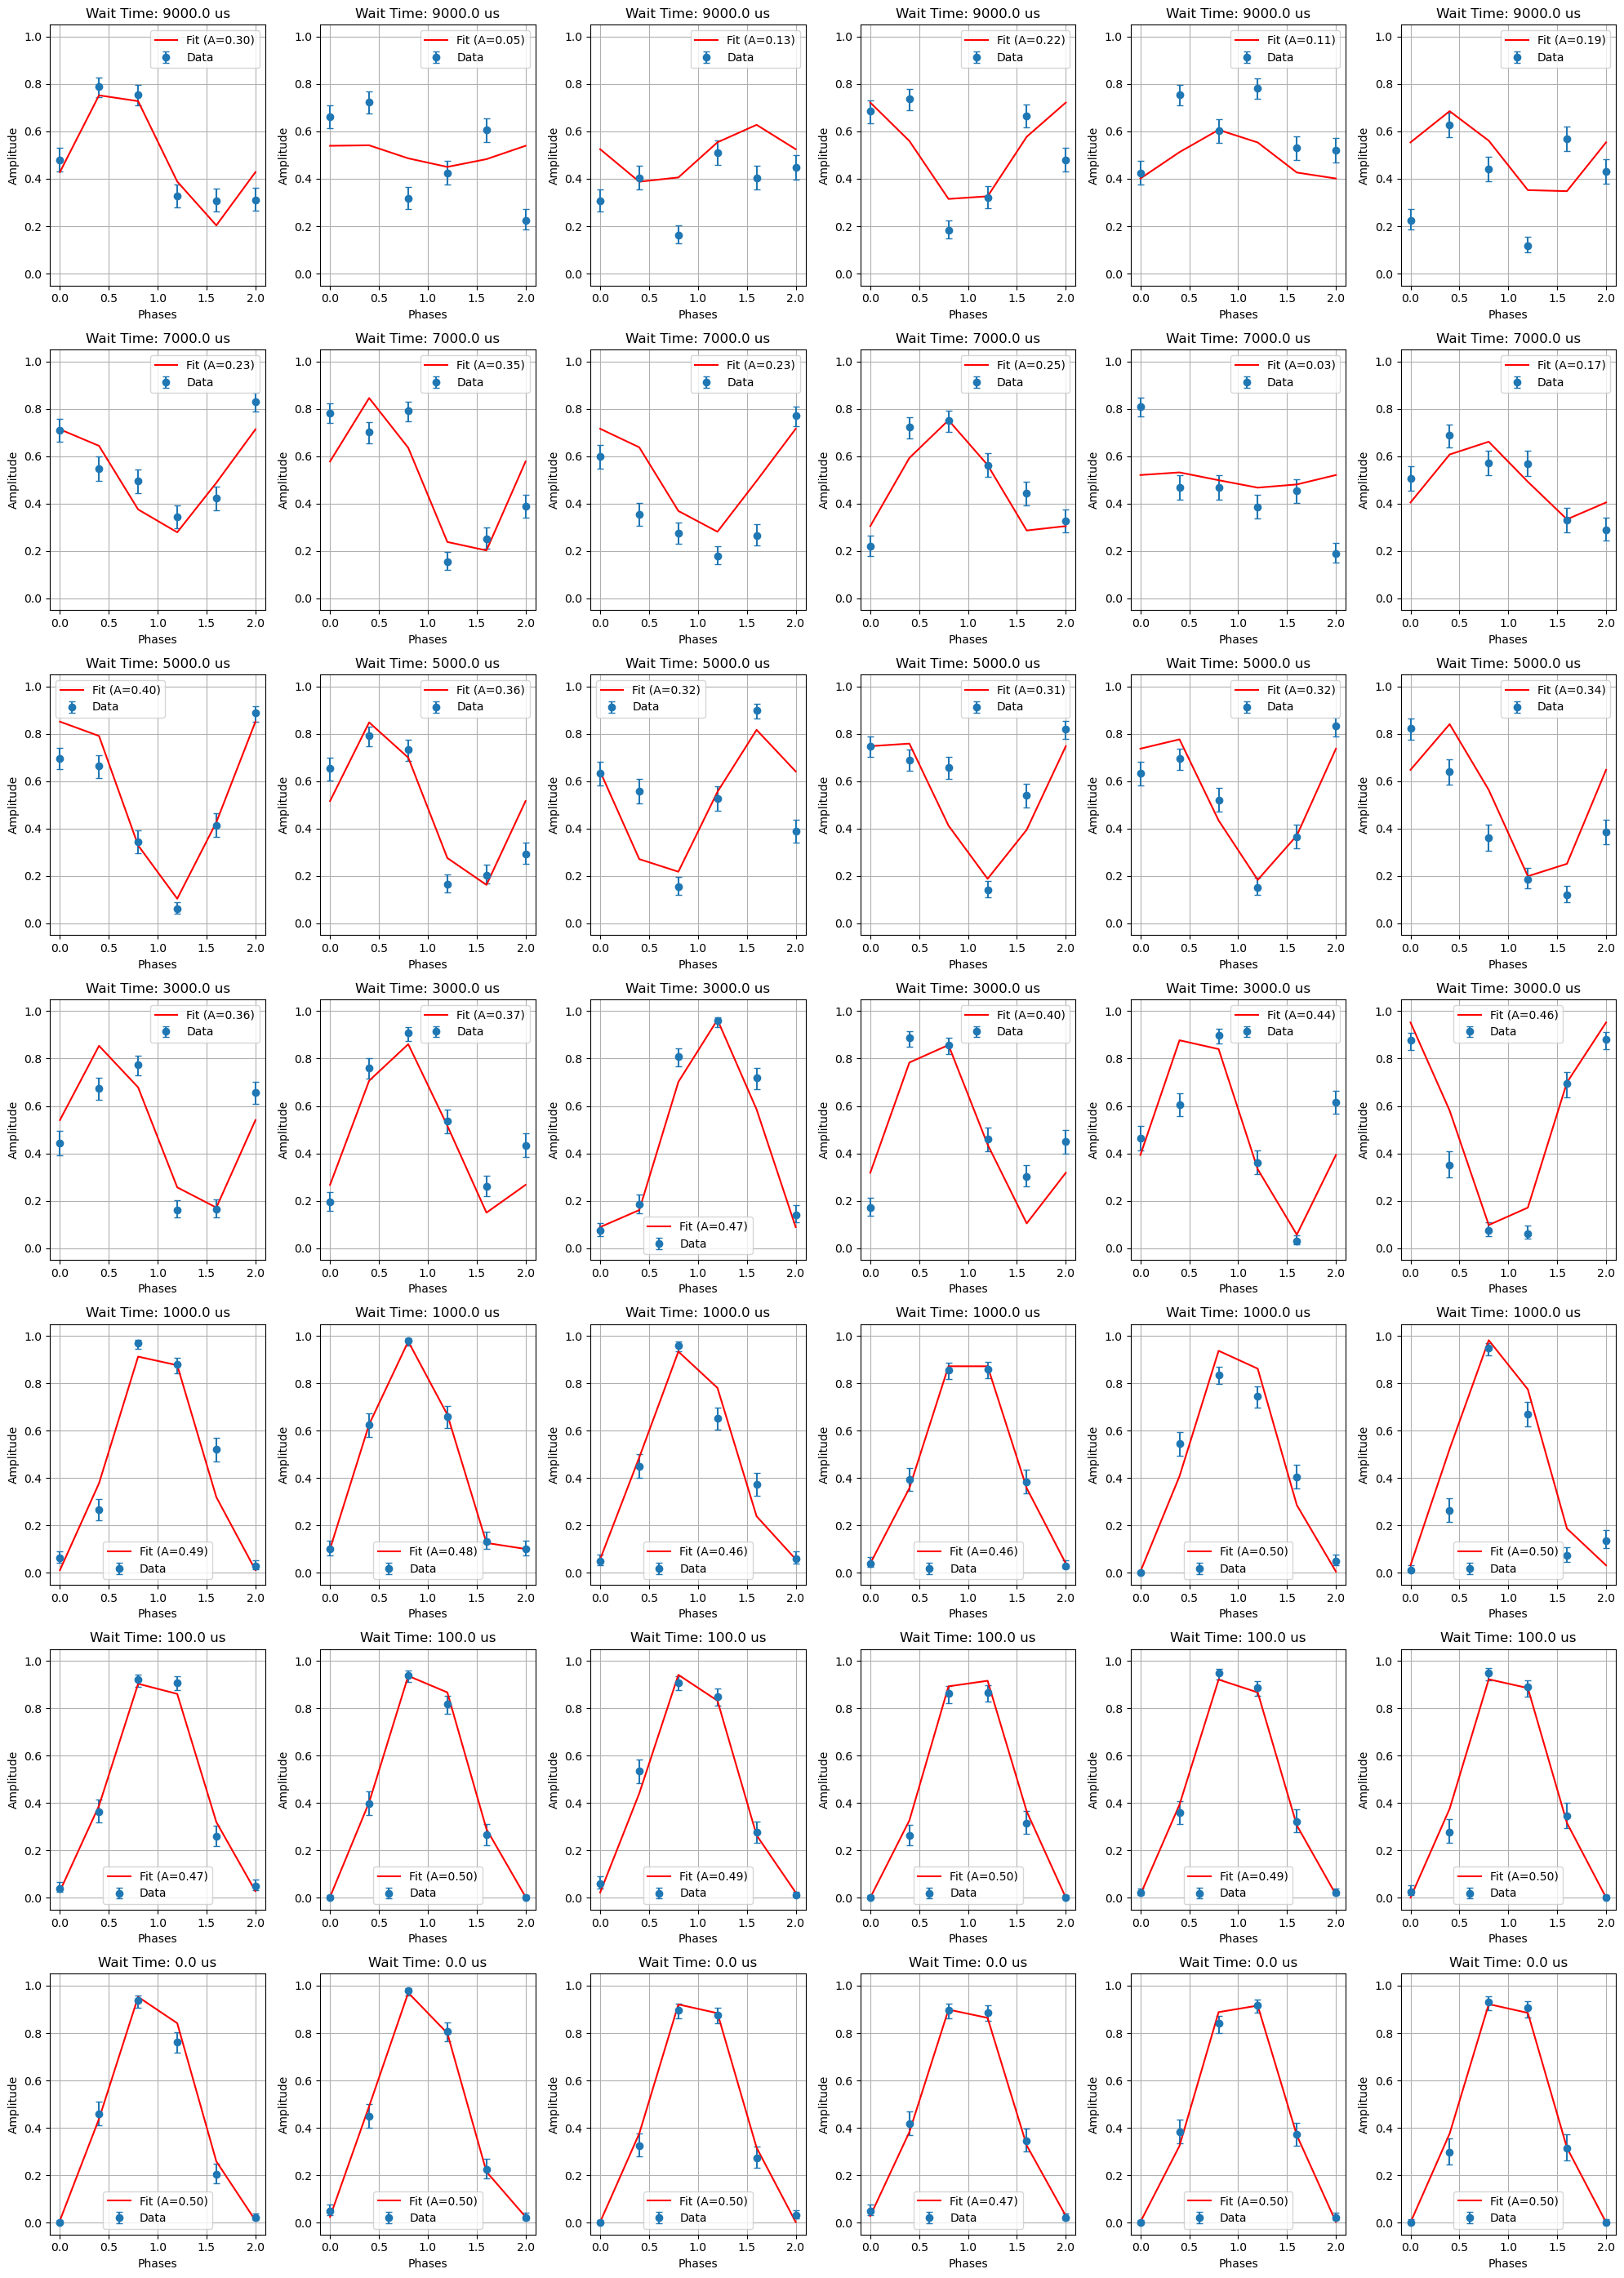


Fitted Results (Lists):
Wait Time: 0.0 us
  Params (A, phi, offset) = 0.500, 6.220, 0.460
  Amplitude (2*|A|) = 1.000 ± 0.010
  Phase = 6.220 ± 0.056
Wait Time: 0.0 us
  Params (A, phi, offset) = 0.498, 0.047, 0.460
  Amplitude (2*|A|) = 0.995 ± 0.010
  Phase = 0.047 ± 0.052
Wait Time: 0.0 us
  Params (A, phi, offset) = 0.473, 6.220, 0.460
  Amplitude (2*|A|) = 0.945 ± 0.023
  Phase = 6.220 ± 0.055
Wait Time: 0.0 us
  Params (A, phi, offset) = 0.498, 6.220, 0.460
  Amplitude (2*|A|) = 0.997 ± 0.010
  Phase = 6.220 ± 0.051
Wait Time: 0.0 us
  Params (A, phi, offset) = 0.497, 5.987, 0.460
  Amplitude (2*|A|) = 0.995 ± 0.020
  Phase = 5.987 ± 0.043
Wait Time: 0.0 us
  Params (A, phi, offset) = 0.500, 6.093, 0.460
  Amplitude (2*|A|) = 1.000 ± 0.013
  Phase = 6.093 ± 0.049
Wait Time: 100.0 us
  Params (A, phi, offset) = 0.500, 6.220, 0.460
  Amplitude (2*|A|) = 1.000 ± 0.011
  Phase = 6.220 ± 0.052
Wait Time: 100.0 us
  Params (A, phi, offset) = 0.489, 6.189, 0.460
  Amplitude (2*|A|) = 0

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def sine_function(t, A, phi, offset):
    offset = 0.5
    return A * np.cos(2 * np.pi/10 * t - phi - np.pi) + offset

def fit_sine_curve(ket_data, lower_error, upper_error):
    # if len(ket_data) == 5:
    #     t = 2*np.arange(len(ket_data))
    # else:
    #     t = np.arange(len(ket_data))
    t = np.linspace(0, 10, len(ket_data))  # Normalize t to span one full period (0 to 10)
    valid_indices = ~np.isnan(ket_data) & ~np.isnan(lower_error) & ~np.isnan(upper_error)
    t_valid = t[valid_indices]
    # print(t_valid)
    ket_data_valid = np.array(ket_data)[valid_indices]
    lower_error_valid = np.array(lower_error)[valid_indices]
    upper_error_valid = np.array(upper_error)[valid_indices]

    sigma = (upper_error_valid + lower_error_valid) / 2.0
    if np.any(sigma <= 0):
        nonzero = sigma[sigma > 0]
        replacement = np.min(nonzero) if len(nonzero) > 0 else 1.0
        sigma[sigma <= 0] = replacement

    A0 = (np.max(ket_data_valid) - np.min(ket_data_valid))/2
    A0 = np.clip(A0, 0.0, 0.5)
    initial_guess = [0.44, np.pi, 0.46]

    try:
        params, covariance = curve_fit(
            sine_function,
            t_valid,
            ket_data_valid,
            p0=initial_guess,
            sigma=sigma,
            absolute_sigma=True,
            maxfev=10000,
            bounds=([0.0, 0, 0], [0.5, 2*np.pi*0.99, 1])
        )
        if covariance is not None:
            errors = np.sqrt(np.diag(covariance))
            errors = [err if np.isfinite(err) else None for err in errors]
        else:
            errors = [None] * len(params)
        return params, errors
    except RuntimeError:
        return None, None


def fit_all_wait_times_to_sine_in_lists(wait_time_list,
                                        ket_data_list,
                                        lower_error_list,
                                        upper_error_list):
    fit_wait_times_list = []
    fit_params_list = []
    fit_amplitudes_list = []
    fit_amplitude_errors_list = []
    fit_phases_list = []
    fit_phase_errors_list = []
    
    for i in range(len(wait_time_list)):
        wt = wait_time_list[i]
        kd = ket_data_list[i]
        le = lower_error_list[i]
        ue = upper_error_list[i]
        
        if len(kd) > 4:
            params, errors = fit_sine_curve(kd, le, ue)
            if params is not None and errors is not None and errors[0] is not None:
                A, phi, offset = params
                amplitude = 2.0 * abs(A)
                amplitude_error = 2.0 * errors[0] if errors[0] is not None else None
                phase_error = errors[1]

                fit_wait_times_list.append(wt)
                fit_params_list.append(params)
                fit_amplitudes_list.append(amplitude)
                fit_amplitude_errors_list.append(amplitude_error)
                fit_phases_list.append(phi)
                fit_phase_errors_list.append(phase_error)
        else:
            fit_wait_times_list.append(wt)
            fit_params_list.append([None, None, None])
            fit_amplitudes_list.append(None)
            fit_amplitude_errors_list.append(None)
            fit_phases_list.append(None)
            fit_phase_errors_list.append(None)
    return (
        fit_wait_times_list,
        fit_params_list,
        fit_amplitudes_list,
        fit_amplitude_errors_list,
        fit_phases_list,
        fit_phase_errors_list
    )

def plot_sine_fits_in_lists(wait_time_list,
                            ket_data_list,
                            lower_error_list,
                            upper_error_list,
                            fit_wait_times_list,
                            fit_params_list):
    num_plots = len(wait_time_list)
    num_columns = 6
    num_rows = (num_plots + num_columns - 1) // num_columns
    fig, axes = plt.subplots(num_rows, num_columns, figsize=(20, 4 * num_rows))
    axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]
    
    for i in range(num_plots):
        wt = wait_time_list[::-1][i]
        kd = ket_data_list[::-1][i]
        le = lower_error_list[::-1][i]
        ue = upper_error_list[::-1][i]
        
        t = np.linspace(0, 10, len(kd))  # Normalize t to span one full period (0 to 10)
        ax = axes[i]
        ax.errorbar(
            np.array(t)*2/10,
            kd,
            yerr=[abs(le), abs(ue)],
            fmt='o',
            label='Data',
            capsize=3
        )
        
        if wt in fit_wait_times_list:
            # NOTE: keeping your original indexing approach unchanged
            j = fit_wait_times_list[::-1].index(wt)
            A, phi, offset = fit_params_list[::-1][i]
            if A is not None:
                fit_curve = sine_function(t, A, phi, offset)
                ax.plot(np.array(t)*2/10, fit_curve, color='red', label=f'Fit (A={A:.2f})')

        ax.set_title(f'Wait Time: {wt} us')
        ax.set_xlabel('Phases')
        ax.set_ylim(-0.05, 1.05)
        ax.set_ylabel('Amplitude')
        ax.grid()
        ax.legend()
    
    for i in range(num_plots, len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.savefig('bussed_ramsey_raw_phase_scans.pdf')
    plt.show()

# --------------------------------------------------------------------
# ONLY PLUMBING CHANGE:
# Use Cell 2 outputs: processed_wait_times, ket_data_list, ...
# --------------------------------------------------------------------
wait_time_list_for_fit = processed_wait_times

(
    fit_wait_times_list,
    fit_params_list,
    fit_amplitudes_list,
    fit_amplitude_errors_list,
    fit_phases_list,
    fit_phase_errors_list
) = fit_all_wait_times_to_sine_in_lists(
    wait_time_list_for_fit,
    ket_data_list,
    lower_error_list,
    upper_error_list
)

plot_sine_fits_in_lists(
    wait_time_list_for_fit,
    ket_data_list,
    lower_error_list,
    upper_error_list,
    fit_wait_times_list,
    fit_params_list
)

print("\nFitted Results (Lists):")
for i, wt in enumerate(fit_wait_times_list):
    A, phi, offset = fit_params_list[i]
    amp = fit_amplitudes_list[i]
    amp_err = fit_amplitude_errors_list[i]
    phase = fit_phases_list[i]
    phase_err = fit_phase_errors_list[i]
    print(f"Wait Time: {wt} us")
    print(f"  Params (A, phi, offset) = {A:.3f}, {phi:.3f}, {offset:.3f}")
    print(f"  Amplitude (2*|A|) = {amp:.3f} ± {amp_err:.3f}")
    print(f"  Phase = {phase:.3f} ± {phase_err:.3f}")


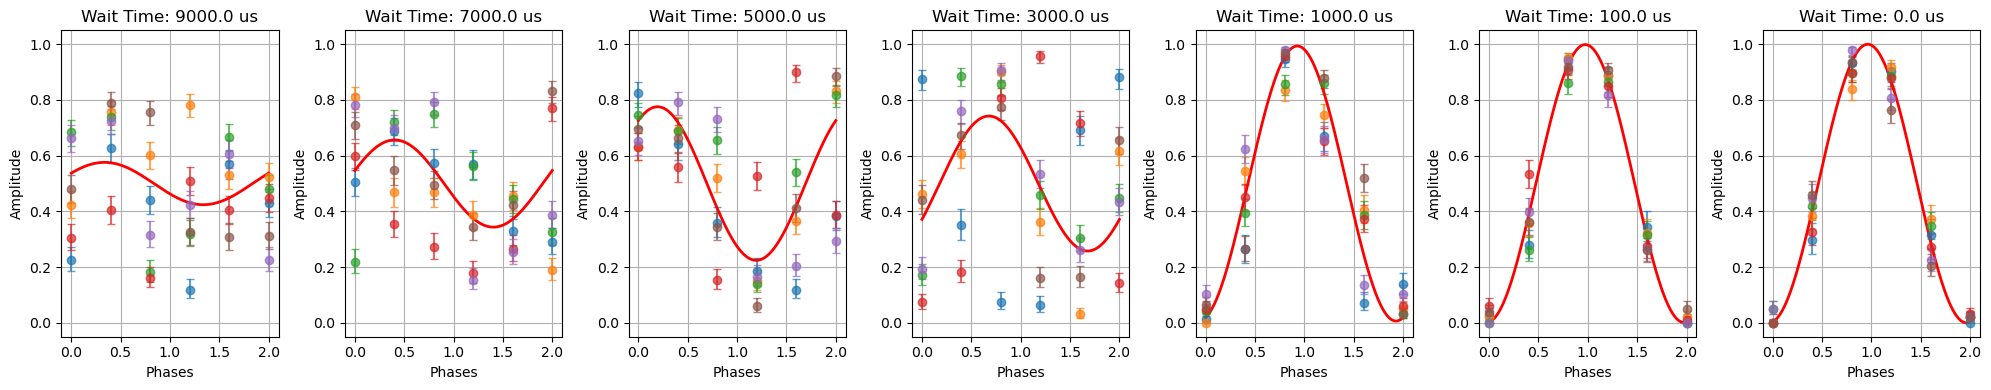


Fitted Results: grouped by wait time
Wait Time: 0.0 us
  Params (A, phi, offset) = 0.500, 6.166, 0.460
  Amplitude (2*|A|) = 1.000 ± 0.005
  Phase = 6.166 ± 0.020
Wait Time: 100.0 us
  Params (A, phi, offset) = 0.499, 6.201, 0.460
  Amplitude (2*|A|) = 0.998 ± 0.004
  Phase = 6.201 ± 0.020
Wait Time: 1000.0 us
  Params (A, phi, offset) = 0.494, 6.060, 0.460
  Amplitude (2*|A|) = 0.987 ± 0.008
  Phase = 6.060 ± 0.019
Wait Time: 3000.0 us
  Params (A, phi, offset) = 0.242, 5.273, 0.460
  Amplitude (2*|A|) = 0.485 ± 0.017
  Phase = 5.273 ± 0.035
Wait Time: 5000.0 us
  Params (A, phi, offset) = 0.276, 3.751, 0.460
  Amplitude (2*|A|) = 0.551 ± 0.019
  Phase = 3.751 ± 0.039
Wait Time: 7000.0 us
  Params (A, phi, offset) = 0.157, 4.408, 0.460
  Amplitude (2*|A|) = 0.313 ± 0.024
  Phase = 4.408 ± 0.065
Wait Time: 9000.0 us
  Params (A, phi, offset) = 0.076, 4.200, 0.460
  Amplitude (2*|A|) = 0.152 ± 0.023
  Phase = 4.200 ± 0.140


In [10]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def sine_function(t, A, phi, offset):
    offset = 0.5
    return A * np.cos(2 * np.pi/10 * t - phi - np.pi) + offset


def fit_sine_curve_combined(kd_group, le_group, ue_group):
    """
    Fit all scans with the same wait time together.
    kd_group, le_group, ue_group are lists of arrays.
    """

    all_t = []
    all_kd = []
    all_sigma = []

    for kd, le, ue in zip(kd_group, le_group, ue_group):
        kd = np.array(kd)
        le = np.array(le)
        ue = np.array(ue)

        t = np.linspace(0, 10, len(kd))

        valid_indices = ~np.isnan(kd) & ~np.isnan(le) & ~np.isnan(ue)

        kd_valid = kd[valid_indices]
        le_valid = le[valid_indices]
        ue_valid = ue[valid_indices]
        t_valid = t[valid_indices]

        sigma = (np.abs(le_valid) + np.abs(ue_valid)) / 2.0

        if np.any(sigma <= 0):
            nonzero = sigma[sigma > 0]
            replacement = np.min(nonzero) if len(nonzero) > 0 else 1.0
            sigma[sigma <= 0] = replacement

        all_t.append(t_valid)
        all_kd.append(kd_valid)
        all_sigma.append(sigma)

    all_t = np.concatenate(all_t)
    all_kd = np.concatenate(all_kd)
    all_sigma = np.concatenate(all_sigma)

    initial_guess = [0.44, np.pi, 0.46]

    try:
        params, covariance = curve_fit(
            sine_function,
            all_t,
            all_kd,
            p0=initial_guess,
            sigma=all_sigma,
            absolute_sigma=True,
            maxfev=10000,
            bounds=([0.0, 0, 0], [0.5, 2*np.pi*0.99, 1])
        )

        errors = np.sqrt(np.diag(covariance))
        errors = [err if np.isfinite(err) else None for err in errors]

        return params, errors

    except RuntimeError:
        return None, None


def fit_grouped_wait_times(wait_time_list,
                           ket_data_list,
                           lower_error_list,
                           upper_error_list):

    grouped_data = defaultdict(lambda: {"kd": [], "le": [], "ue": []})

    for wt, kd, le, ue in zip(
        wait_time_list,
        ket_data_list,
        lower_error_list,
        upper_error_list
    ):
        grouped_data[wt]["kd"].append(kd)
        grouped_data[wt]["le"].append(le)
        grouped_data[wt]["ue"].append(ue)

    fit_wait_times_list = []
    fit_params_list = []
    fit_amplitudes_list = []
    fit_amplitude_errors_list = []
    fit_phases_list = []
    fit_phase_errors_list = []

    for wt in sorted(grouped_data.keys()):
        kd_group = grouped_data[wt]["kd"]
        le_group = grouped_data[wt]["le"]
        ue_group = grouped_data[wt]["ue"]

        total_points = sum(len(kd) for kd in kd_group)

        if total_points > 4:
            params, errors = fit_sine_curve_combined(kd_group, le_group, ue_group)

            if params is not None and errors is not None:
                A, phi, offset = params

                fit_wait_times_list.append(wt)
                fit_params_list.append(params)
                fit_amplitudes_list.append(2.0 * abs(A))
                fit_amplitude_errors_list.append(2.0 * errors[0])
                fit_phases_list.append(phi)
                fit_phase_errors_list.append(errors[1])
            else:
                fit_wait_times_list.append(wt)
                fit_params_list.append([None, None, None])
                fit_amplitudes_list.append(None)
                fit_amplitude_errors_list.append(None)
                fit_phases_list.append(None)
                fit_phase_errors_list.append(None)

    return (
        grouped_data,
        fit_wait_times_list,
        fit_params_list,
        fit_amplitudes_list,
        fit_amplitude_errors_list,
        fit_phases_list,
        fit_phase_errors_list
    )


def plot_grouped_sine_fits(grouped_data,
                           fit_wait_times_list,
                           fit_params_list):

    unique_wait_times = sorted(grouped_data.keys())[::-1]

    num_plots = len(unique_wait_times)
    num_columns = 7
    num_rows = (num_plots + num_columns - 1) // num_columns

    fig, axes = plt.subplots(num_rows, num_columns, figsize=(20, 4 * num_rows))
    axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]

    fit_dict = {
        wt: params
        for wt, params in zip(fit_wait_times_list, fit_params_list)
    }

    for i, wt in enumerate(unique_wait_times):
        ax = axes[i]

        kd_group = grouped_data[wt]["kd"]
        le_group = grouped_data[wt]["le"]
        ue_group = grouped_data[wt]["ue"]

        for scan_index, (kd, le, ue) in enumerate(zip(kd_group, le_group, ue_group)):
            kd = np.array(kd)
            le = np.array(le)
            ue = np.array(ue)

            t = np.linspace(0, 10, len(kd))
            phase_axis = t * 2 / 10

            ax.errorbar(
                phase_axis,
                kd,
                yerr=[np.abs(le), np.abs(ue)],
                fmt='o',
                capsize=3,
                alpha=0.7,
                label=f'Data {scan_index + 1}'
            )

        if wt in fit_dict:
            A, phi, offset = fit_dict[wt]

            if A is not None:
                t_fit = np.linspace(0, 10, 500)
                phase_fit = t_fit * 2 / 10
                fit_curve = sine_function(t_fit, A, phi, offset)

                ax.plot(
                    phase_fit,
                    fit_curve,
                    color='red',
                    linewidth=2,
                    label=f'Combined fit, A={A:.2f}'
                )

        ax.set_title(f'Wait Time: {wt} us')
        ax.set_xlabel('Phases')
        ax.set_ylabel('Amplitude')
        ax.set_ylim(-0.05, 1.05)
        ax.grid()
        # ax.legend(fontsize=8)

    for i in range(num_plots, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.savefig('bussed_ramsey_grouped_phase_scans.pdf')
    plt.show()

wait_time_list_for_fit = processed_wait_times

(
    grouped_data,
    fit_wait_times_list,
    fit_params_list,
    fit_amplitudes_list,
    fit_amplitude_errors_list,
    fit_phases_list,
    fit_phase_errors_list
) = fit_grouped_wait_times(
    wait_time_list_for_fit,
    ket_data_list,
    lower_error_list,
    upper_error_list
)

plot_grouped_sine_fits(
    grouped_data,
    fit_wait_times_list,
    fit_params_list
)

print("\nFitted Results: grouped by wait time")
for i, wt in enumerate(fit_wait_times_list):
    A, phi, offset = fit_params_list[i]
    amp = fit_amplitudes_list[i]
    amp_err = fit_amplitude_errors_list[i]
    phase = fit_phases_list[i]
    phase_err = fit_phase_errors_list[i]

    print(f"Wait Time: {wt} us")

    if A is None:
        print("  Fit failed")
    else:
        print(f"  Params (A, phi, offset) = {A:.3f}, {phi:.3f}, {offset:.3f}")
        print(f"  Amplitude (2*|A|) = {amp:.3f} ± {amp_err:.3f}")
        print(f"  Phase = {phase:.3f} ± {phase_err:.3f}")

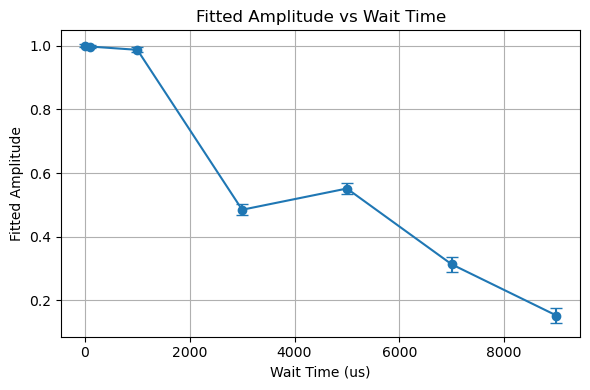

In [11]:
# Plot fitted amplitude vs wait time

import numpy as np
import matplotlib.pyplot as plt

# Keep only successful fits
valid_data = [
    (wt, amp, amp_err)
    for wt, amp, amp_err in zip(
        fit_wait_times_list,
        fit_amplitudes_list,
        fit_amplitude_errors_list
    )
    if amp is not None
]

# Sort by wait time
valid_data = sorted(valid_data, key=lambda x: x[0])

wait_times = np.array([x[0] for x in valid_data])
amplitudes = np.array([x[1] for x in valid_data])
amplitude_errors = np.array([x[2] for x in valid_data])

plt.figure(figsize=(6, 4))
plt.errorbar(
    wait_times,
    amplitudes,
    yerr=amplitude_errors,
    fmt='o-',
    capsize=4
)

plt.xlabel('Wait Time (us)')
plt.ylabel('Fitted Amplitude')
# plt.xscale('log')
plt.title('Fitted Amplitude vs Wait Time')
plt.grid(True)
plt.tight_layout()
plt.show()